## Import The Dataset

In [ ]:
import numpy as np
import time
import copy
import os
import torch
import torch.optim as optim
import torch.nn as nn
import torchvision
import matplotlib.pyplot as plt
from torch.optim import lr_scheduler
from torchvision import datasets, models, transforms

## Data Preprocessing

In [ ]:
transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
}

data_dir = 'data'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), transform=transforms[x])
                  for x in ['train', 'val', 'test']}
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4, shuffle=True, num_workers=4)
               for x in ['train', 'val', 'test']}
data_size = {x: len(image_datasets[x]) for x in ['train', 'val', 'test']}
class_names = image_datasets['train'].classes
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [ ]:
dataiter = iter(dataloaders['train'])
images, labels = next(dataiter)

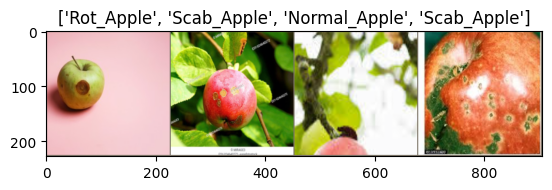

In [ ]:
def imshow(inp, title=None):
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)
    
out = torchvision.utils.make_grid(images)
imshow(out, title=[class_names[x] for x in labels])

## Create a function to train and to evaluate the model

In [ ]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()
    
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    
    for epoch in range(num_epochs):
        print('Epoch {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)
        
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()
                
            running_loss = 0.0
            running_corrects = 0
            
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)
                
                optimizer.zero_grad()
                
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                        
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
                
            if phase == 'train':
                scheduler.step()
                
            epoch_loss = running_loss / data_size[phase]
            epoch_acc = running_corrects.double() / data_size[phase]
            
            print('{} Loss: {:.4f} Acc: {:.4f}'.format(
                phase, epoch_loss, epoch_acc))
            
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
        print()
    
    time_elapsed = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format(
        time_elapsed // 60, time_elapsed % 60))
    print('Best val Acc: {:4f}'.format(best_acc))
    
    model.load_state_dict(best_model_wts)
    return model

## Declare and Download (optional) the pretrained model

In [ ]:
model_resnet = models.resnet18(pretrained=True)

C:\Users\admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
model_vgg16 = models.vgg16(pretrained=True)

C:\Users\admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
model_inceptionv3 = models.inception_v3(pretrained=True)

C:\Users\admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
model_alexnet = models.alexnet(pretrained=True)


C:\Users\admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


# Set the model, parameters to tune, criterion, oprimizer, and the weight update

### VGG-16 Architecture

In [ ]:
for param in model_vgg16.parameters():
    param.requires_grad = False

num_ftrs = model_vgg16.classifier[6].in_features
model_vgg16.classifier[6] = nn.Linear(num_ftrs, len(class_names))
model_vgg16 = model_vgg16.to(device)
criterion = nn.CrossEntropyLoss()
optimizer_conv = optim.SGD(model_vgg16.classifier[6].parameters(), lr=0.001, momentum=0.9)
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_conv, step_size=7, gamma=0.1)

In [16]:
model_vgg16 = train_model(model_vgg16, criterion, optimizer_conv, exp_lr_scheduler, num_epochs=25)

Epoch 0/24
----------


KeyboardInterrupt: 

### ResNet Architecture

In [ ]:
for param in model_resnet.parameters():
    param.requires_grad = False

num_ftrs = model_resnet.fc.in_features
model_resnet.fc = nn.Linear(num_ftrs, len(class_names))
model_resnet = model_resnet.to(device)
criterion = nn.CrossEntropyLoss()
optimizer_conv = optim.SGD(model_resnet.fc.parameters(), lr=0.001, momentum=0.9)
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_conv, step_size=7, gamma=0.1)

In [ ]:
model_resnet = train_model(model_resnet, criterion, optimizer_conv, exp_lr_scheduler, num_epochs=25)

Epoch 0/24
----------
train Loss: 0.7371 Acc: 0.7169
val Loss: 0.1657 Acc: 0.9451

Epoch 1/24
----------
train Loss: 0.5070 Acc: 0.8186
val Loss: 0.4219 Acc: 0.8667

Epoch 2/24
----------
train Loss: 0.5123 Acc: 0.8129
val Loss: 0.1185 Acc: 0.9686

Epoch 3/24
----------
train Loss: 0.4666 Acc: 0.8195
val Loss: 0.1564 Acc: 0.9490

Epoch 4/24
----------
train Loss: 0.4934 Acc: 0.8138
val Loss: 0.1348 Acc: 0.9412

Epoch 5/24
----------
train Loss: 0.4705 Acc: 0.8335
val Loss: 0.1478 Acc: 0.9451

Epoch 6/24
----------
train Loss: 0.4945 Acc: 0.8361
val Loss: 0.2615 Acc: 0.9137

Epoch 7/24
----------
train Loss: 0.3440 Acc: 0.8755
val Loss: 0.1270 Acc: 0.9529

Epoch 8/24
----------
train Loss: 0.3856 Acc: 0.8602
val Loss: 0.1140 Acc: 0.9608

Epoch 9/24
----------
train Loss: 0.3970 Acc: 0.8585
val Loss: 0.1541 Acc: 0.9569

Epoch 10/24
----------
train Loss: 0.3724 Acc: 0.8646
val Loss: 0.1361 Acc: 0.9529

Epoch 11/24
----------
train Loss: 0.3592 Acc: 0.8681
val Loss: 0.0968 Acc: 0.9725

Ep

In [ ]:
for param in model_resnet.parameters():
    param.requires_grad = False

num_ftrs = model_resnet.fc.in_features
model_resnet.fc = nn.Linear(num_ftrs, len(class_names))
model_resnet = model_resnet.to(device)
criterion = nn.CrossEntropyLoss()
optimizer_conv = optim.SGD(model_resnet.fc.parameters(), lr=0.001, momentum=0.9)
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_conv, step_size=7, gamma=0.1)

In [ ]:
model_resnet = train_model(model_resnet, criterion, optimizer_conv, exp_lr_scheduler, num_epochs=25)

Epoch 0/24
----------
train Loss: 0.7371 Acc: 0.7125
val Loss: 0.2688 Acc: 0.8980

Epoch 1/24
----------
train Loss: 0.5265 Acc: 0.7971
val Loss: 0.1712 Acc: 0.9373

Epoch 2/24
----------
train Loss: 0.4860 Acc: 0.8234
val Loss: 0.1287 Acc: 0.9647

Epoch 3/24
----------
train Loss: 0.4537 Acc: 0.8339
val Loss: 0.1215 Acc: 0.9647

Epoch 4/24
----------
train Loss: 0.4521 Acc: 0.8401
val Loss: 0.2041 Acc: 0.9294

Epoch 5/24
----------
train Loss: 0.4399 Acc: 0.8401
val Loss: 0.1308 Acc: 0.9569

Epoch 6/24
----------
train Loss: 0.4691 Acc: 0.8317
val Loss: 0.1388 Acc: 0.9608

Epoch 7/24
----------
train Loss: 0.3809 Acc: 0.8699
val Loss: 0.1200 Acc: 0.9569

Epoch 8/24
----------
train Loss: 0.3448 Acc: 0.8773
val Loss: 0.1240 Acc: 0.9608

Epoch 9/24
----------
train Loss: 0.3521 Acc: 0.8707
val Loss: 0.1277 Acc: 0.9647

Epoch 10/24
----------
train Loss: 0.3596 Acc: 0.8646
val Loss: 0.1041 Acc: 0.9569

Epoch 11/24
----------
train Loss: 0.3461 Acc: 0.8729
val Loss: 0.1191 Acc: 0.9529

Ep

In [ ]:
model_resnet

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### AlexNet Architecture

In [ ]:
for param in model_alexnet.parameters():
    param.requires_grad = False

num_ftrs = model_alexnet.classifier[6].in_features
model_alexnet.classifier[6] = nn.Linear(num_ftrs, len(class_names))
model_alexnet = model_alexnet.to(device)
criterion = nn.CrossEntropyLoss()
optimizer_conv = optim.SGD(model_alexnet.classifier[6].parameters(), lr=0.001, momentum=0.9)
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_conv, step_size=7, gamma=0.1)

In [ ]:
model_alexnet = train_model(model_alexnet, criterion, optimizer_conv, exp_lr_scheduler, num_epochs=25)

Epoch 0/24
----------
train Loss: 0.8375 Acc: 0.8120
val Loss: 0.2159 Acc: 0.9294

Epoch 1/24
----------
train Loss: 0.6694 Acc: 0.8611
val Loss: 0.4107 Acc: 0.9059

Epoch 2/24
----------
train Loss: 0.7279 Acc: 0.8580
val Loss: 0.6434 Acc: 0.9059

Epoch 3/24
----------
train Loss: 0.7737 Acc: 0.8738
val Loss: 0.6665 Acc: 0.9020

Epoch 4/24
----------
train Loss: 0.7403 Acc: 0.8659
val Loss: 0.7661 Acc: 0.8863

Epoch 5/24
----------
train Loss: 0.8122 Acc: 0.8734
val Loss: 0.2579 Acc: 0.9451

Epoch 6/24
----------
train Loss: 0.6703 Acc: 0.8786
val Loss: 0.8203 Acc: 0.8902

Epoch 7/24
----------
train Loss: 0.4436 Acc: 0.9032
val Loss: 0.3155 Acc: 0.9255

Epoch 8/24
----------
train Loss: 0.4100 Acc: 0.9154
val Loss: 0.3369 Acc: 0.9098

Epoch 9/24
----------
train Loss: 0.2970 Acc: 0.9290
val Loss: 0.2007 Acc: 0.9569

Epoch 10/24
----------
train Loss: 0.3512 Acc: 0.9233
val Loss: 0.2529 Acc: 0.9255

Epoch 11/24
----------
train Loss: 0.3661 Acc: 0.9211
val Loss: 0.1642 Acc: 0.9647

Ep

In [ ]:
model_alexnet

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

### Test the model

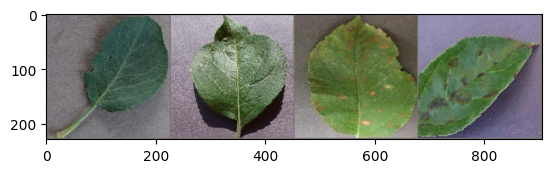

GroundTruth:  Healthy, Healthy, Cedar Apple Rust, Apple Scab
Predicted:  Healthy, Healthy, Cedar Apple Rust, Apple Scab


In [ ]:
dataiter = iter(dataloaders['test'])
images, labels = next(dataiter)
imshow(torchvision.utils.make_grid(images))
print('GroundTruth: ', ', '.join('%5s' % class_names[x] for x in labels))
images = images.to(device)
labels = images.to(device)
output = model_resnet(images)
_, predicted = torch.max(output, 1)
print('Predicted: ', ', '.join('%5s' % class_names[x] for x in predicted))

### Save the model

In [ ]:
# Save The Model
PATH = './fix_resnet18.pth'
torch.save(model_resnet.state_dict(), PATH)

NameError: name 'torch' is not defined

In [ ]:
import os

# Specify the path to the model
model_path = './fix_resnet18.pth'

# Check if the file exists
if os.path.exists(model_path):
    print(f"The model is saved at: {model_path}")
else:
    print(f"The model is not saved at: {model_path}")


The model is saved at: ./fix_resnet18.pth


In [ ]:
from pathlib import Path

# Specify the path to the model
model_path = Path('./fix_resnet18.pth')

# Check if the file exists
if model_path.is_file():
    print(f"The model is saved at: {model_path}")
else:
    print(f"The model is not saved at: {model_path}")


The model is saved at: fix_resnet18.pth


In [ ]:
import torch

model_path = './fix_resnet18.pth'

try:
    model = torch.load(model_path)
    print("Model loaded successfully!")
except Exception as e:
    print(f"Error loading model: {e}")


Model loaded successfully!


C:\Users\admin\AppData\Local\Temp\ipykernel_12932\3885963182.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(model_path)


In [4]:
import torch

model_path = './fix_resnet18.pth'

try:
    model_weights = torch.load(model_path)
    print("Model weights loaded successfully!")
except Exception as e:
    print(f"Error loading model weights: {e}")


Model weights loaded successfully!


C:\Users\admin\AppData\Local\Temp\ipykernel_13044\1467315893.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_weights = torch.load(model_path)
